In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import zeta

In [8]:
#Constants
Q = 1.29          # neutron proton mass difference [MeV]
B_D = 2.2        # deuterium binding energy [MeV]
m_N = 939.0        # neutron mass [MeV]
tau_n = 886.0      # neutron lifetime [s]

eta_default = 6.1e-10 #baryon-photon ratio

#Unit conversion
T9_IN_MEV = 0.086       # 10^9 K in MeV
ZETA3 = zeta(3)
MEV3_TO_CM3 = (5.068e10)**3 # 1 MeV = 5.068e10 cm^{-1}
H1 = 1.13   # s^{-1} 

In [23]:
def gstar(Neff=3.0):
    return 2.0 + (7.0 / 8.0) * (4.0 + 2.0 * Neff)


def H1_eff(Neff=3.0):
    return H1 * np.sqrt(gstar(Neff) / 10.75)


def Hubble_x(x, Neff=3.0):
    return H1_eff(Neff) / x**2

#convert from x to T
def T_of_x(x):
    return Q / x

#photon number density
def n_gamma(T):    
    return (2.0 * ZETA3 / np.pi**2) * T**3 * MEV3_TO_CM3

#baryon number density
def n_baryon(T, eta):
    return eta * n_gamma(T)



def Gamma_np_x(x):
    """
    Gamma_np = (255/tau_n) (12 + 6x + x^2)/x^5.
    """
    return (255.0 / tau_n) * (12.0 + 6.0*x + x**2) / x**5



def Reaction_rates(T):
    """
    Returns <\sigma v> in cm^3 s^-1
    """

    T9 = max(T / T9_IN_MEV, 1e-30)
    #n + p <-> D+gamma
    sig_np = 6.0e-20 
    #D + p -> He-3+gamma
    sig_Dp = (
        8.0e-21 * T9**(-2.0/3.0) * np.exp(-3.7 * T9**(-1.0/3.0))
    )
    #D+D->T+p or D+D->He-3+n
    sig_DD_all = (
        3.0e-15 * T9**(-2.0/3.0) * np.exp(-4.26 * T9**(-1.0/3.0))
    )

    sig_DD_Tp = 0.5 * sig_DD_all
    sig_DD_He3n = 0.5 * sig_DD_all
    #D+He-3 -> He-4+p
    sig_DHe3 = (
        1.0e-15 * T9**(-1.0/2.0) * np.exp(-1.8 * T9**(-1.0))
    )
    #D+T -> He-4+n
    sig_DT = (
        1.0e-15 * T9**(-2.0/3.0) * np.exp(-0.5 * T9**(-1.0))
    )

    return sig_np, sig_Dp, sig_DD_Tp, sig_DD_He3n, sig_DHe3, sig_DT



#For Deuterium Bottleneck need to consider D\gamma -> n+p
def saha_factor_D(T, eta):
    """
    X_D^eq = S_D(T) X_n X_p

    S_D(T) = 8.1 eta (T/m_N)^{3/2} exp(B_D/T).
    """

    exponent = min(B_D / T, 700.0)

    return 8.1 * eta * (T / m_N)**1.5 * np.exp(exponent)



# RHS of the system of Boltzmann eqns with x = Q/T

def rhs_x(
    x,
    y,
    eta=eta_default,
    Neff=3.0,
    include_free_neutron_decay=True
):
    """
    Variables:
        y = [X_n, X_D, X_T, X_3, X_4]
    Proton abundance is eliminated using
        X_p = 1 - X_n - 2X_D - 3X_T - 3X_3 - 4X_4.
    """

    Xn, XD, XT, X3, X4 = y

    # Avoid tiny negative values inside rates
    Xn_rate = max(Xn, 0.0)
    XD_rate = max(XD, 0.0)
    XT_rate = max(XT, 0.0)
    X3_rate = max(X3, 0.0)
    X4_rate = max(X4, 0.0)

    Xp = (
        1 - Xn_rate - 2*XD_rate - 3*XT_rate - 3*X3_rate - 4*X4_rate
    )

    Xp_rate = max(Xp, 0.0)

    T = T_of_x(x)
    H = Hubble_x(x, Neff)
    nb = n_baryon(T, eta)

    
    
    

    G = Gamma_np_x(x)

    W = G * (Xn_rate - np.exp(-x) * Xp_rate)
    #neutron decay
    if include_free_neutron_decay:
        W += Xn_rate / tau_n

    

    sig_np, sig_Dp, sig_DD_Tp, sig_DD_He3n, sig_DHe3, sig_DT = (Reaction_rates(T))

    # n + p <-> D + gamma
    S_D = saha_factor_D(T, eta)

    
    R_D = nb * sig_np * (
        Xn_rate * Xp_rate - XD_rate / max(S_D, 1e-300)
    )

    #D + p -> He-3+gamma
    R_Dp = nb * sig_Dp * XD_rate * Xp_rate

    #D+D->T+p
    # Factor 1/2 for identical initial-state D particles
    R_DD_Tp = 0.5 * nb * sig_DD_Tp * XD_rate**2

    #D+D->He-3+n
    R_DD_He3n = 0.5 * nb * sig_DD_He3n * XD_rate**2

    #D+He-3 -> He-4+p
    R_DHe3 = nb * sig_DHe3 * XD_rate * X3_rate

    #D+T -> He-4+n
    R_DT = nb * sig_DT * XD_rate * XT_rate

    #Boltzmann eqns

    dXn_dt = (-W - R_D + R_DD_He3n + R_DT)

    dXD_dt = (+ R_D - R_Dp - 2.0*R_DD_Tp - 2.0*R_DD_He3n - R_DHe3 - R_DT)

    dXT_dt = (+ R_DD_Tp - R_DT)

    dX3_dt = (+ R_Dp + R_DD_He3n - R_DHe3)

    dX4_dt = (+ R_DHe3 + R_DT)

    dXdt = np.array([dXn_dt, dXD_dt, dXT_dt, dX3_dt, dX4_dt])

    
    # dX/dx = dX/dt / (dx/dt) = x/H1 * dX/dt.
    dXdx = dXdt / (H * x)

    return dXdx




def initial_conditions_x(Ti, eta):
    x_i = Q / Ti

    # equilibrium Xn/Xp = exp(-x)
    Xn_i = 1.0 / (1.0 + np.exp(x_i))
    Xp_i = 1.0 - Xn_i

    # Deuterium equilibrium
    XD_i = saha_factor_D(Ti, eta) * Xn_i * Xp_i

    tiny = 1e-40

    return np.array([Xn_i, max(XD_i, tiny),tiny,tiny,tiny])


def solve_bbn_x(
    eta=eta_default,
    Neff=3.0,
    Ti=10.0,
    Tf=0.02,
    include_free_neutron_decay=True,
    method="Radau",
    rtol=1e-7,
    atol=1e-18,
    n_eval=1500
):


    x_i = Q / Ti
    x_f = Q / Tf

    y0 = initial_conditions_x(Ti, eta)

    x_eval = np.geomspace(x_i, x_f, n_eval)

    sol = solve_ivp(
        fun=lambda x, y: rhs_x(
            x,
            y,
            eta=eta,
            Neff=Neff,
            include_free_neutron_decay=include_free_neutron_decay
        ),
        t_span=(x_i, x_f),
        y0=y0,
        t_eval=x_eval,
        method=method,
        rtol=rtol,
        atol=atol,
    )

    return sol



def unpack_solution_x(sol):
    x = sol.t
    T = Q / x

    Xn, XD, XT, X3, X4 = sol.y

    #For positive abundances
    Xn = np.clip(Xn, 0.0, None)
    XD = np.clip(XD, 0.0, None)
    XT = np.clip(XT, 0.0, None)
    X3 = np.clip(X3, 0.0, None)
    X4 = np.clip(X4, 0.0, None)

    Xp = 1.0 - Xn - 2.0*XD - 3.0*XT - 3.0*X3 - 4.0*X4

    mass_n = Xn
    mass_p = Xp
    mass_D = 2.0 * XD
    mass_T = 3.0 * XT
    mass_3 = 3.0 * X3
    mass_4 = 4.0 * X4

    baryon_sum = mass_n + mass_p + mass_D + mass_T + mass_3 + mass_4

    return {
        "x": x,
        "T": T,
        "Xn": Xn,
        "Xp": Xp,
        "XD": XD,
        "XT": XT,
        "X3": X3,
        "X4": X4,
        "mass_n": mass_n,
        "mass_p": mass_p,
        "mass_D": mass_D,
        "mass_T": mass_T,
        "mass_3": mass_3,
        "mass_4": mass_4,
        "baryon_sum": baryon_sum,
    }


    




    





In [24]:
sol = solve_bbn_x(
    eta=6.1e-10,
    Neff=3.0,
    Ti=10.0,
    Tf=0.02,
    include_free_neutron_decay=True
)

if not sol.success:
    print(sol.message)

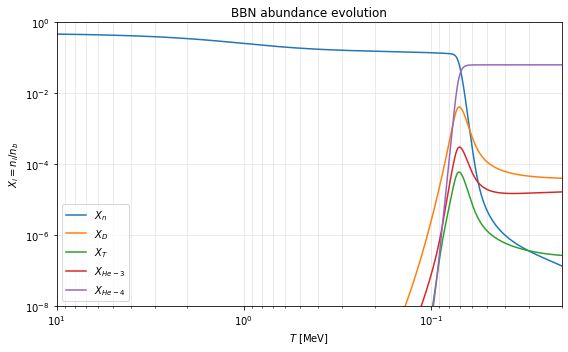

In [25]:
data = unpack_solution_x(sol)
T = data["T"]

plt.figure(figsize=(8, 5))

plt.plot(T, data["Xn"], label=r"$X_n$")
plt.plot(T, data["XD"], label=r"$X_D$")
plt.plot(T, data["XT"], label=r"$X_T$")
plt.plot(T, data["X3"], label=r"$X_{He-3}$")
plt.plot(T, data["X4"], label=r"$X_{He-4}$")
plt.xscale("log")
plt.yscale("log")

plt.xlim(T[0], T[-1])  
plt.ylim(1e-8, 1.0)
plt.grid(alpha=0.3, which="both")
plt.xlabel(r"$T$ [MeV]")
plt.ylabel(r"$X_i=n_i/n_b$")
plt.title("BBN abundance evolution")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
Xn_f = data["Xn"][-1]
Xp_f = data["Xp"][-1]
XD_f = data["XD"][-1]
XT_f = data["XT"][-1]
X3_f = data["X3"][-1]
X4_f = data["X4"][-1]

print("Final number abundances X_i = n_i/n_b:")
print(f"X_n        = {Xn_f:.4e}")
print(f"X_p        = {Xp_f:.4e}")
print(f"X_D        = {XD_f:.4e}")
print(f"X_T        = {XT_f:.4e}")
print(f"X_He3      = {X3_f:.4e}")
print(f"X_He4      = {X4_f:.4e}")

print("\nFinal mass fractions A_i X_i:")
print(f"n          = {Xn_f:.4e}")
print(f"p          = {Xp_f:.4e}")
print(f"D          = {2.0*XD_f:.4e}")
print(f"T          = {3.0*XT_f:.4e}")
print(f"He3        = {3.0*X3_f:.4e}")
print(f"He4        = {4.0*X4_f:.4e}")

baryon_sum = (Xn_f+ Xp_f+ 2.0*XD_f+ 3.0*XT_f+ 3.0*X3_f+ 4.0*X4_f)

print(f"\nBaryon sum = {baryon_sum:.8f}")

Final number abundances X_i = n_i/n_b:
X_n        = 1.3713e-07
X_p        = 7.4561e-01
X_D        = 4.0507e-05
X_T        = 2.7071e-07
X_He3      = 1.6635e-05
X_He4      = 6.3564e-02

Final mass fractions A_i X_i:
n          = 1.3713e-07
p          = 7.4561e-01
D          = 8.1014e-05
T          = 8.1213e-07
He3        = 4.9906e-05
He4        = 2.5426e-01

Baryon sum = 1.00000000


In [31]:
def final_abundances_for_eta(
    eta,
    Neff=3.0,
    Ti=10.0,
    Tf=0.02,
    include_free_neutron_decay=True
):
    """
    Return final number abundances X_i = n_i/n_b
    for a given eta.
    """

    sol = solve_bbn_x(
        eta=eta,
        Neff=Neff,
        Ti=Ti,
        Tf=Tf,
        include_free_neutron_decay=include_free_neutron_decay,
        n_eval=800
    )

    if not sol.success:
        print("Warning:", sol.message)

    data = unpack_solution_x(sol)

    return {
        "Xn": data["Xn"][-1],
        "Xp": data["Xp"][-1],
        "XD": data["XD"][-1],
        "XT": data["XT"][-1],
        "X3": data["X3"][-1],
        "X4": data["X4"][-1],
        "YHe4_mass": data["mass_4"][-1],
    }


def abundance_eta_scan(
    eta10_min=1.0,
    eta10_max=10.0,
    n_points=40,
    Neff=3.0,
    Ti=10.0,
    Tf=0.02,
    include_free_neutron_decay=True,
    plot_He3=False
):
    """
    Scan final D, T, and He4 number abundances versus eta
    """

    eta10_grid = np.linspace(eta10_min, eta10_max, n_points)

    XD_values = []
    XT_values = []
    X3_values = []
    X4_values = []
    YHe4_mass_values = []

    for eta10 in eta10_grid:
        eta = eta10 * 1e-10

        abund = final_abundances_for_eta(
            eta=eta,
            Neff=Neff,
            Ti=Ti,
            Tf=Tf,
            include_free_neutron_decay=include_free_neutron_decay
        )

        XD_values.append(abund["XD"])
        XT_values.append(abund["XT"])
        X3_values.append(abund["X3"])
        X4_values.append(abund["X4"])
        YHe4_mass_values.append(abund["YHe4_mass"])
        
    XD_values = np.array(XD_values)
    XT_values = np.array(XT_values)
    X3_values = np.array(X3_values)
    X4_values = np.array(X4_values)
    YHe4_mass_values = np.array(YHe4_mass_values)
    
    results = {
        "eta10": eta10_grid,
        "XD": XD_values,
        "XT": XT_values,
        "X3": X3_values,
        "X4": X4_values,
        "YHe4_mass": YHe4_mass_values,
    }

    return results

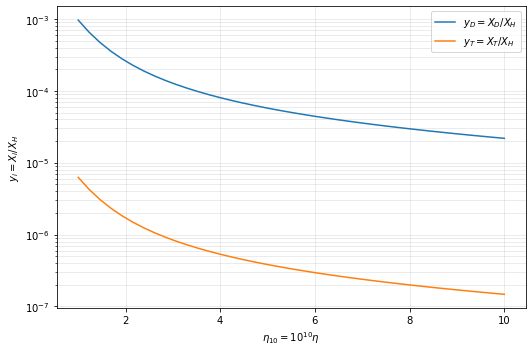

In [36]:
results_eta = abundance_eta_scan(
    eta10_min=1.0,
    eta10_max=10.0,
    n_points=40,
    Neff=3.0,
    Ti=10.0,
    Tf=0.02,
    include_free_neutron_decay=True,
    plot_He3=True
)

eta10_grid = results_eta["eta10"]
XD_values = results_eta["XD"]
XT_values = results_eta["XT"]
X3_values = results_eta["X3"]
X4_values = results_eta["X4"]
YHe4_mass_values = results_eta["YHe4_mass"]

XH = 1 - XD_values - XT_values - X3_values - X4_values

yD = XD_values/XH
yT = XT_values/XH


plt.figure(figsize=(7.5, 5))
plt.semilogy(
        eta10_grid,
        yD,
        label=r"$y_D=X_D/X_H$"
    )

plt.semilogy(
        eta10_grid,
        yT,
        label=r"$y_T=X_T/X_H$"
    )

plt.yscale("log")

plt.xlabel(r"$\eta_{10}=10^{10}\eta$")
plt.ylabel(r"$y_i=X_i/X_H$")

plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

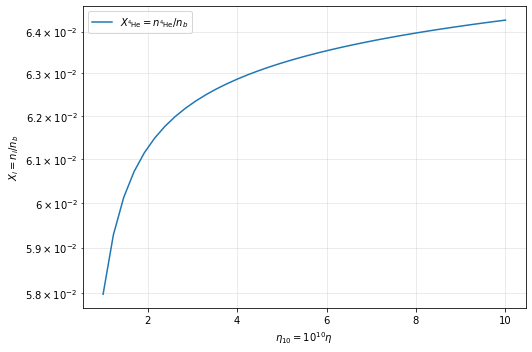

In [34]:
plt.figure(figsize=(7.5, 5))
plt.plot(
        eta10_grid,
        X4_values,
        label=r"$X_{{}^4{\rm He}}=n_{{}^4{\rm He}}/n_b$"
    )
plt.yscale("log")

plt.xlabel(r"$\eta_{10}=10^{10}\eta$")
plt.ylabel(r"$X_i=n_i/n_b$")

plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()